# Lab 4: Getting Started with Image Processing Using scikit-image

This notebook implements Tasks 0-6 from the lab specification using the two image files
supplied with the lab: `images/coins.jpg` and `images/astronaut.jpg`.

## Task 0 - Software setup

Install the packages from the repository root with `pip install -r requirements.txt`.

In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage import data, io
from skimage.color import rgb2gray
from skimage.transform import rescale, resize
from skimage.feature import match_template
from skimage.util import img_as_float

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["image.cmap"] = "gray"

# This works both from the repository root and from notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
IMAGE_DIR = PROJECT_ROOT / "images"
coins_path = IMAGE_DIR / "coins.jpg"
astronaut_path = IMAGE_DIR / "astronaut.jpg"
if not coins_path.exists() or not astronaut_path.exists():
    raise FileNotFoundError("Place the supplied coins.jpg and astronaut.jpg files in images/")

print(f"scikit-image version: {skimage.__version__}")
print(f"Images: {IMAGE_DIR.resolve()}")

scikit-image version: 0.26.0
Images: C:\Files\Learn\LTU\Programming for Machine Learning D0036E 17562 HT2026\Labs\Lab 4\lab-4-image-processing-scikit-image\images


## Task 1 - Load and visualize images

For each image we report shape, dtype, and a sample pixel intensity, then display it. The supplied
`coins.jpg` is already 2-D grayscale, so its sample is `[1, 100]`. The supplied `astronaut.jpg`
is RGB, so `[1, 100, 1]` selects its green channel.

coins.jpg: shape=(303, 384), dtype=uint8, pixel[1,100]=133
astronaut.jpg: shape=(512, 512, 3), dtype=uint8, pixel[1,100,1]=174


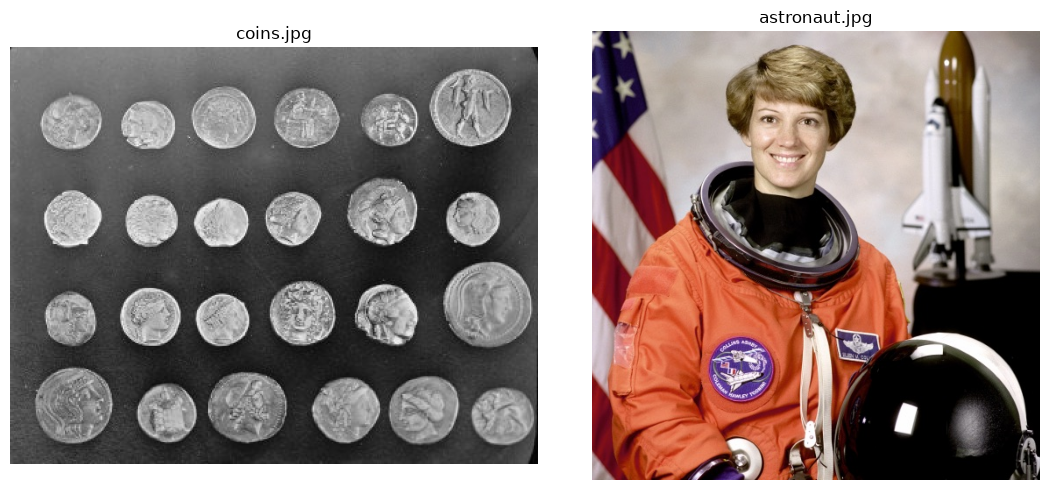

In [2]:
coins = io.imread(coins_path)
astronaut = io.imread(astronaut_path)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, image, name in zip(axes, [coins, astronaut], ["coins.jpg", "astronaut.jpg"]):
    sample = image[1, 100] if image.ndim == 2 else image[1, 100, 1]
    sample_index = "[1,100]" if image.ndim == 2 else "[1,100,1]"
    print(f"{name}: shape={image.shape}, dtype={image.dtype}, pixel{sample_index}={sample}")
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Task 2 - Color-space conversion

The supplied coins image is already grayscale, so it only needs conversion from `uint8` values
in [0, 255] to floating-point values in [0, 1]. `rgb2gray` converts the astronaut from
`(height, width, 3)` RGB to `(height, width)` grayscale while also returning floating point.

coins    : (303, 384), uint8 -> (303, 384), float64; range [0.004, 0.984]
astronaut: (512, 512, 3), uint8 -> (512, 512), float64; range [0.000, 1.000]


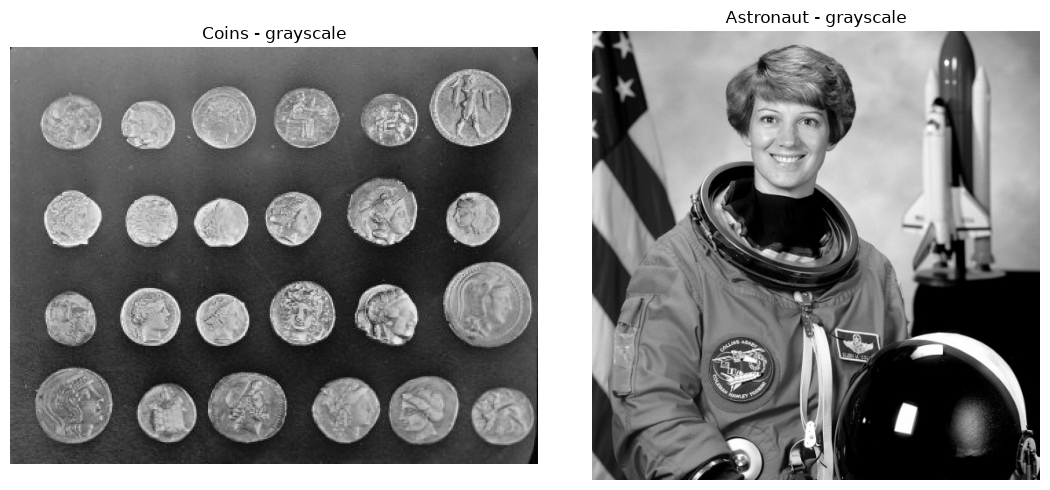

In [3]:
coins_gray = img_as_float(coins)
astronaut_gray = rgb2gray(astronaut)

for name, original, grayscale in [
    ("coins", coins, coins_gray),
    ("astronaut", astronaut, astronaut_gray),
]:
    print(f"{name:9s}: {original.shape}, {original.dtype} -> {grayscale.shape}, {grayscale.dtype}; "
          f"range [{grayscale.min():.3f}, {grayscale.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(coins_gray, cmap="gray")
axes[0].set_title("Coins - grayscale")
axes[1].imshow(astronaut_gray, cmap="gray")
axes[1].set_title("Astronaut - grayscale")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Task 3 - Image rescale and resize

`resize` targets an exact output height and width; here the astronaut is resized to 300 x 200.
`rescale` instead multiplies both spatial dimensions by a factor, preserving aspect ratio.
Anti-aliasing reduces jagged edges and moire when downsampling.

Original: (512, 512, 3)
Resized to chosen dimensions: (300, 200, 3)
Rescaled by 0.75: (384, 384, 3)
Rescaled by 0.5: (256, 256, 3)
Rescaled by 0.25: (128, 128, 3)


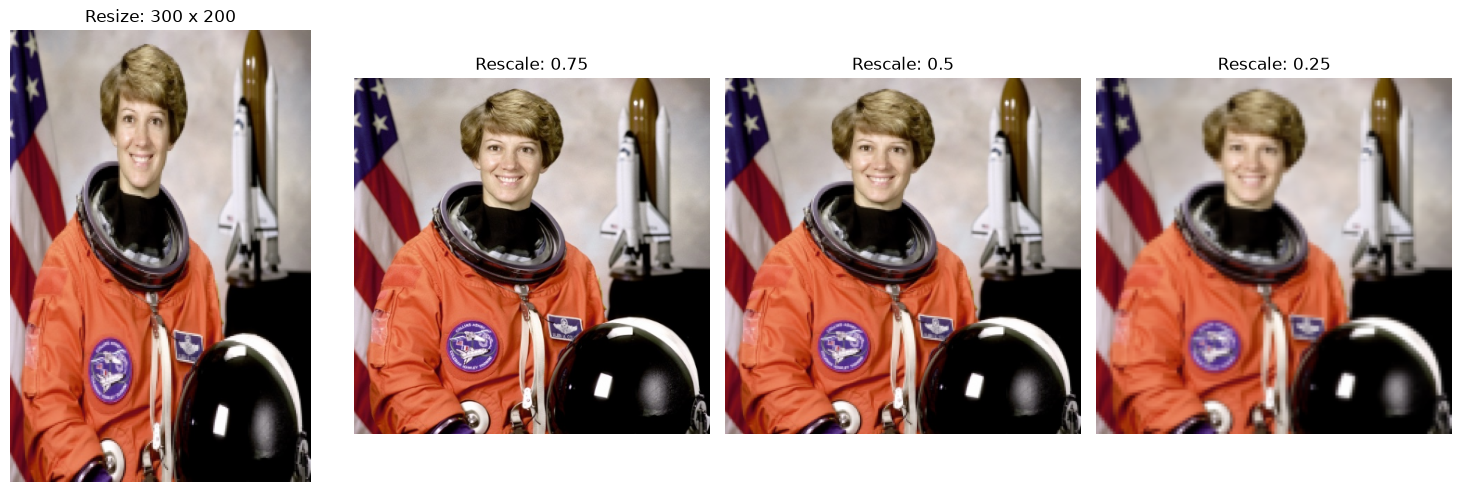

In [4]:
astronaut_resized = resize(astronaut, (300, 200), anti_aliasing=True)
scale_factors = [0.75, 0.5, 0.25]
astronaut_rescaled = {
    factor: rescale(astronaut, factor, channel_axis=-1, anti_aliasing=True)
    for factor in scale_factors
}

print(f"Original: {astronaut.shape}")
print(f"Resized to chosen dimensions: {astronaut_resized.shape}")
for factor, image in astronaut_rescaled.items():
    print(f"Rescaled by {factor}: {image.shape}")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(astronaut_resized)
axes[0].set_title("Resize: 300 x 200")
for ax, (factor, image) in zip(axes[1:], astronaut_rescaled.items()):
    ax.imshow(image)
    ax.set_title(f"Rescale: {factor}")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Task 4 - Image thresholding

The grayscale image is `float64`, so its intensities are in [0, 1]. Inspection of the histogram
shows a useful separation near **t = 0.42**. Following the lab's suggested expression,
`coins_gray < t` marks darker pixels as `True`. The result is Boolean; reversing the comparison
would instead make bright coin regions white.

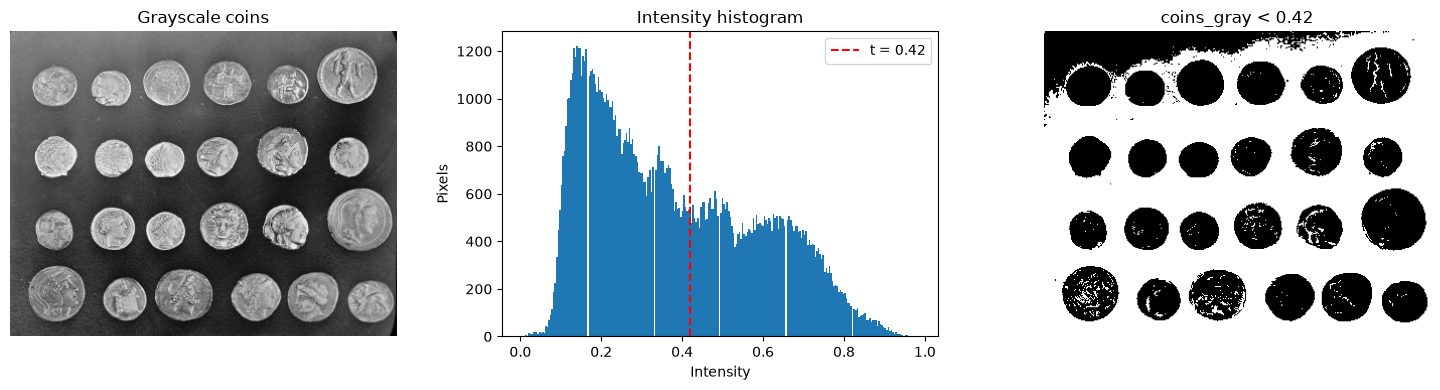

grayscale dtype=float64; binary dtype=bool


In [5]:
t = 0.42
binary = coins_gray < t

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(coins_gray, cmap="gray")
axes[0].set_title("Grayscale coins")
axes[0].axis("off")
axes[1].hist(coins_gray.ravel(), bins=256)
axes[1].axvline(t, color="red", linestyle="--", label=f"t = {t}")
axes[1].set(title="Intensity histogram", xlabel="Intensity", ylabel="Pixels")
axes[1].legend()
axes[2].imshow(binary, cmap="gray")
axes[2].set_title(f"coins_gray < {t}")
axes[2].axis("off")
plt.tight_layout()
plt.show()
print(f"grayscale dtype={coins_gray.dtype}; binary dtype={binary.dtype}")

## Task 5 - Template matching with scikit-image

The template is a crop containing one coin. `match_template` calculates normalized correlation
at every valid location. The brightest response (maximum correlation) is the best match, and the
red rectangle maps that response back onto the original image. Because the template itself comes
from the image, its source location should be the strongest match.

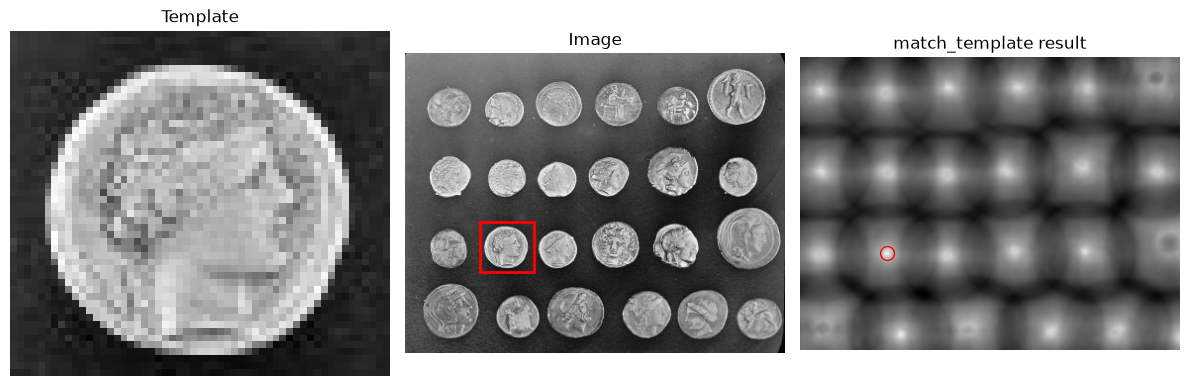

Best top-left position: (x=75, y=170); score=1.000000


In [6]:
template_image = data.coins()
coin = template_image[170:220, 75:130]
result = match_template(template_image, coin)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

fig = plt.figure(figsize=(12, 4))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2)
ax3 = plt.subplot(1, 3, 3)
ax1.imshow(coin)
ax1.set_title("Template")
ax2.imshow(template_image)
ax2.set_title("Image")
hcoin, wcoin = coin.shape
ax2.add_patch(plt.Rectangle((x, y), wcoin, hcoin, edgecolor="red", facecolor="none", linewidth=2))
ax3.imshow(result)
ax3.plot(x, y, "o", markeredgecolor="red", markerfacecolor="none", markersize=10)
ax3.set_title("match_template result")
for ax in (ax1, ax2, ax3): ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Best top-left position: (x={x}, y={y}); score={result[y, x]:.6f}")

## Task 6 - Own template-matching implementation

Below is a simple normalized cross-correlation (NCC) implementation. It does not call
`skimage.feature.match_template`. Two ordinary `for` loops move the template over the image.
At each position, the code compares the template with the image patch. Scores close to 1 indicate
a strong match. This version favors clarity over speed so that every step is easy to follow.

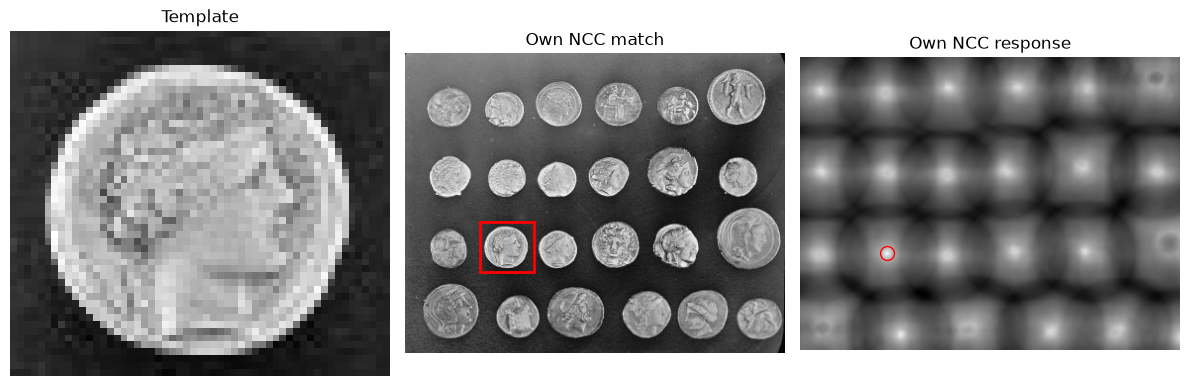

Own NCC position: (x=75, y=170); score=1.000000
scikit-image position: (x=75, y=170)
Same best location: True


In [7]:
def normalized_cross_correlation(image, template):
    """Find template similarity at every valid position using simple NCC."""
    image = image.astype(float)
    template = template.astype(float)

    image_height, image_width = image.shape
    template_height, template_width = template.shape

    result_height = image_height - template_height + 1
    result_width = image_width - template_width + 1
    result = np.zeros((result_height, result_width))

    template_zero_mean = template - np.mean(template)
    template_length = np.sqrt(np.sum(template_zero_mean ** 2))

    for y in range(result_height):
        for x in range(result_width):
            patch = image[y:y + template_height, x:x + template_width]
            patch_zero_mean = patch - np.mean(patch)

            numerator = np.sum(patch_zero_mean * template_zero_mean)
            patch_length = np.sqrt(np.sum(patch_zero_mean ** 2))
            denominator = patch_length * template_length

            if denominator != 0:
                result[y, x] = numerator / denominator

    return result


own_result = normalized_cross_correlation(template_image, coin)
own_y, own_x = np.unravel_index(np.argmax(own_result), own_result.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(coin)
axes[0].set_title("Template")
axes[1].imshow(template_image)
axes[1].add_patch(plt.Rectangle((own_x, own_y), wcoin, hcoin,
                                edgecolor="red", facecolor="none", linewidth=2))
axes[1].set_title("Own NCC match")
axes[2].imshow(own_result)
axes[2].plot(own_x, own_y, "o", markeredgecolor="red", markerfacecolor="none", markersize=10)
axes[2].set_title("Own NCC response")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Own NCC position: (x={own_x}, y={own_y}); score={own_result[own_y, own_x]:.6f}")
print(f"scikit-image position: (x={x}, y={y})")
print(f"Same best location: {(own_x, own_y) == (x, y)}")

## Conclusion

The notebook loaded and inspected RGB data, converted it to grayscale, changed spatial scale,
performed manual threshold segmentation, and located a template using both scikit-image and an
independent NCC implementation. The two template matchers are checked against each other by
comparing their best-match coordinates.